In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv('car_set.csv')
df.columns = [col.upper() for col in df.columns]
df.head()

,TRIP_ID,CAR_NAME,VEHICLE_TYPE,FUEL_TYPE,TRIP_CATEGORY,DISTANCE_KM,TRIP_DURATION_HR,AVG_SPEED_KMPH,BASE_MILEAGE_KMPL,ACTUAL_MILEAGE_KMPL,MILEAGE_DELTA_KMPL,FUEL_CONSUMED_L,FUEL_COST_USD,COST_PER_KM_USD,CO2_EMISSIONS_KG,CO2_PER_KM,RELATIVE_EFFICIENCY,EFFICIENCY_BAND
0,1,Lexus ES,Luxury,Diesel,Very Long (>400 km),437.85,4.84,90.51,11.31,11.24,-0.07,38.96,44.59,0.1018,104.413,0.2385,0.5979,Average
1,2,Lexus ES,Luxury,Petrol,Medium (50–200 km),181.86,3.54,51.43,9.98,9.61,-0.37,18.92,23.93,0.1316,43.705,0.2403,0.5113,Poor
2,3,Audi A6,Luxury,Petrol,Medium (50–200 km),118.07,1.46,80.62,11.06,11.24,0.18,10.50,13.28,0.1125,24.255,0.2054,0.5982,Average
3,4,Maruti Swift,Hatchback,Diesel,Long (200–400 km),343.16,4.72,72.65,21.17,19.65,-1.52,17.46,19.98,0.0582,46.793,0.1364,0.7181,Average
4,5,Hyundai Creta,SUV,Diesel,Long (200–400 km),371.03,3.87,95.78,13.01,12.39,-0.62,29.95,34.28,0.0924,80.266,0.2163,0.5717,Average


In [4]:
numeric_cols = ['DISTANCE_KM', 'AVG_SPEED_KMPH', 'BASE_MILEAGE_KMPL', 'ACTUAL_MILEAGE_KMPL']
stats_summary = df[numeric_cols].describe().T
stats_summary['median'] = df[numeric_cols].median()
stats_summary = stats_summary[['count', 'mean', 'std', 'min', '50%', 'max']].round(2)
stats_summary.columns = ['Count', 'Mean', 'Std Dev', 'Min', 'Median', 'Max']

print("Table 1: Descriptive Statistics for Vehicle Telemetry")
stats_summary

Table 1: Descriptive Statistics for Vehicle Telemetry


,Count,Mean,Std Dev,Min,Median,Max
DISTANCE_KM,600.0,260.70,137.13,20.11,264.79,499.47
AVG_SPEED_KMPH,600.0,79.28,22.79,40.07,78.72,119.95
BASE_MILEAGE_KMPL,600.0,15.90,3.71,8.02,15.30,24.99
ACTUAL_MILEAGE_KMPL,600.0,15.94,3.87,7.38,15.48,27.37


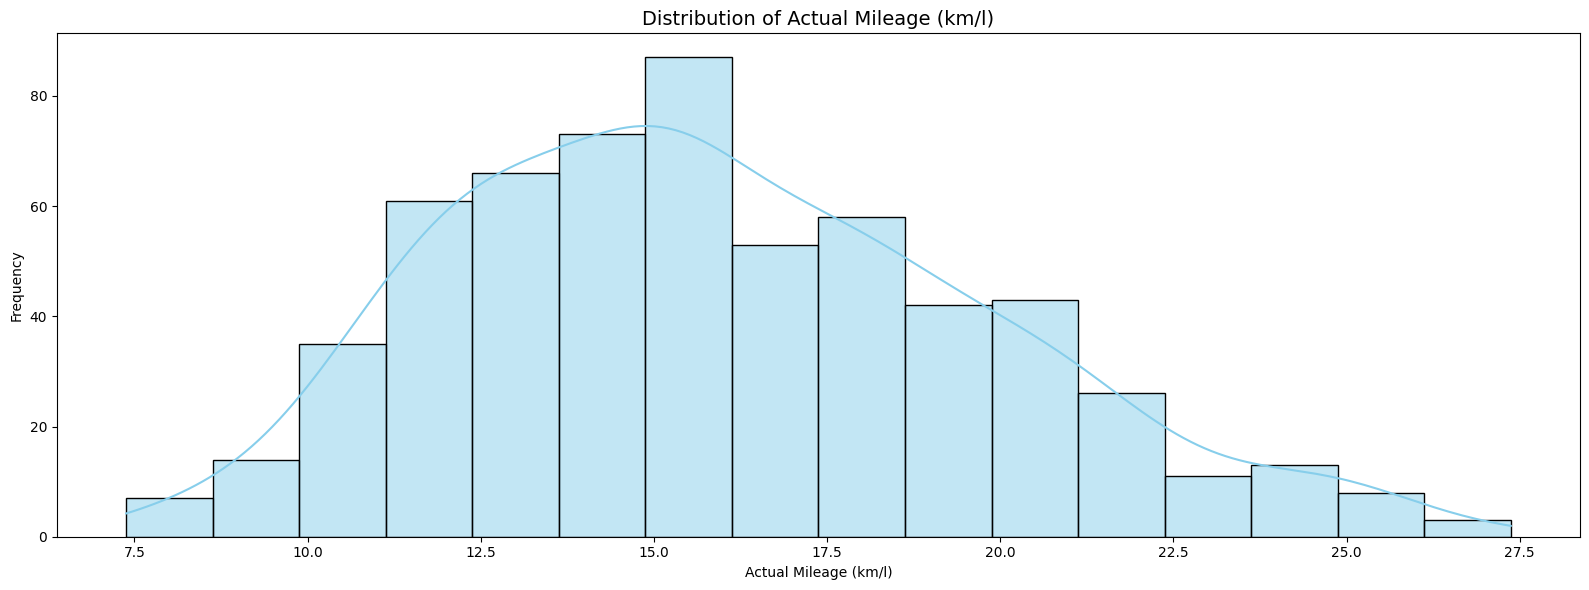

In [5]:
fig, ax1 = plt.subplots(1, 1, figsize=(16, 6))

sns.histplot(df['ACTUAL_MILEAGE_KMPL'], kde=True, ax=ax1, color='skyblue')
ax1.set_title('Distribution of Actual Mileage (km/l)', fontsize=14)
ax1.set_xlabel('Actual Mileage (km/l)')
ax1.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

<Figure size 1200x700 with 0 Axes>

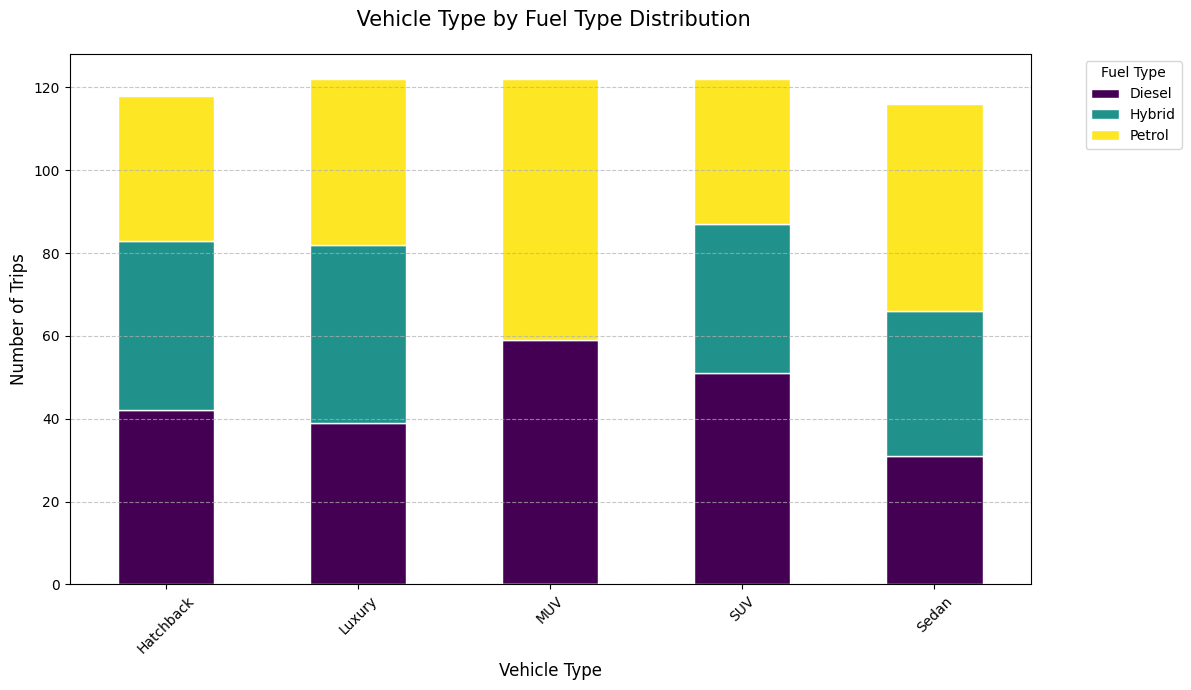

In [6]:
plt.figure(figsize=(12, 7))

composition_data = pd.crosstab(df['VEHICLE_TYPE'], df['FUEL_TYPE'])
composition_data.plot(kind='bar', stacked=True, figsize=(12, 7),
                      colormap='viridis', edgecolor='white')

plt.title(' Vehicle Type by Fuel Type Distribution', fontsize=15, pad=20)
plt.xlabel('Vehicle Type', fontsize=12)
plt.ylabel('Number of Trips', fontsize=12)
plt.legend(title='Fuel Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

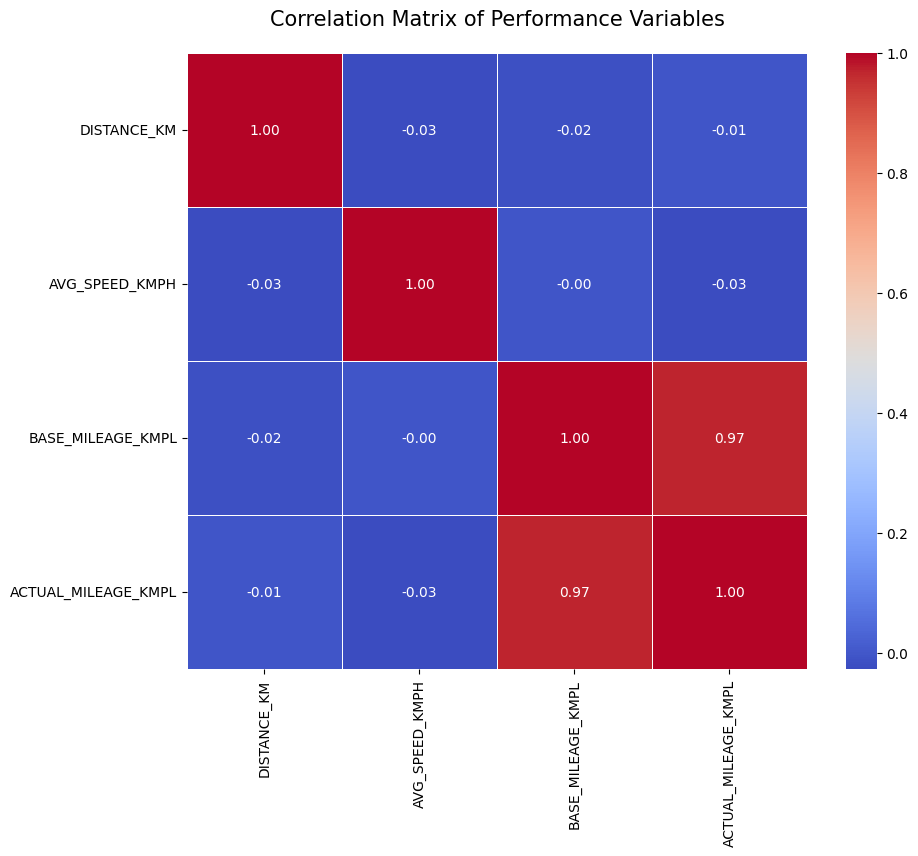

In [7]:
numeric_cols = ['DISTANCE_KM', 'AVG_SPEED_KMPH', 'BASE_MILEAGE_KMPL', 'ACTUAL_MILEAGE_KMPL']

plt.figure(figsize=(10, 8))
correlation_matrix = df[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Performance Variables', fontsize=15, pad=20)
plt.show()

In [10]:
print(f"Dataset Shape: {df.shape}")
print(f"\nColumn Names:\n{df.columns.tolist()}")

Dataset Shape: (600, 18)

Column Names:
['TRIP_ID', 'CAR_NAME', 'VEHICLE_TYPE', 'FUEL_TYPE', 'TRIP_CATEGORY', 'DISTANCE_KM', 'TRIP_DURATION_HR', 'AVG_SPEED_KMPH', 'BASE_MILEAGE_KMPL', 'ACTUAL_MILEAGE_KMPL', 'MILEAGE_DELTA_KMPL', 'FUEL_CONSUMED_L', 'FUEL_COST_USD', 'COST_PER_KM_USD', 'CO2_EMISSIONS_KG', 'CO2_PER_KM', 'RELATIVE_EFFICIENCY', 'EFFICIENCY_BAND']


In [11]:
# Q1: Efficiency Ranking by Vehicle & Fuel Type
q1_efficiency = df.groupby(['VEHICLE_TYPE', 'FUEL_TYPE'])['ACTUAL_MILEAGE_KMPL'].mean().reset_index()
q1_efficiency.rename(columns={'ACTUAL_MILEAGE_KMPL': 'AVG_EFFICIENCY'}, inplace=True)
q1_efficiency['AVG_EFFICIENCY'] = q1_efficiency['AVG_EFFICIENCY'].round(3)
q1_efficiency['EFFICIENCY_RANK'] = q1_efficiency['AVG_EFFICIENCY'].rank(method='min', ascending=False).astype(int)
q1_efficiency = q1_efficiency.sort_values('EFFICIENCY_RANK').reset_index(drop=True)
q1_efficiency

,VEHICLE_TYPE,FUEL_TYPE,AVG_EFFICIENCY,EFFICIENCY_RANK
0,Hatchback,Hybrid,23.063,1
1,Sedan,Hybrid,21.434,2
2,Hatchback,Diesel,19.930,3
3,SUV,Hybrid,17.860,4
4,Hatchback,Petrol,17.807,5
5,Sedan,Diesel,17.570,6
6,Sedan,Petrol,15.991,7
7,Luxury,Hybrid,15.391,8
8,MUV,Diesel,15.296,9
9,SUV,Diesel,14.123,10


In [12]:
#Q2: Impact of Speed on Mileage
bins = [-float('inf'), 39.99, 70, 100, float('inf')]
labels = ['Low Speed (<40)', 'Medium Speed (40-70)', 'High Speed (70-100)', 'Very High Speed (>100)']
df['SPEED_BUCKET'] = pd.cut(df['AVG_SPEED_KMPH'], bins=bins, labels=labels)

q2_speed = df.groupby('SPEED_BUCKET', observed=False).agg(
    AVG_VARIANCE=('MILEAGE_DELTA_KMPL', 'mean'),
    TRIP_COUNT=('MILEAGE_DELTA_KMPL', 'count')
).reset_index()

q2_speed['AVG_VARIANCE'] = q2_speed['AVG_VARIANCE'].round(3)
q2_speed = q2_speed.sort_values('AVG_VARIANCE', ascending=True).reset_index(drop=True)
q2_speed

,SPEED_BUCKET,AVG_VARIANCE,TRIP_COUNT
0,Very High Speed (>100),-0.065,142
1,High Speed (70-100),0.018,230
2,Medium Speed (40-70),0.115,228
3,Low Speed (<40),NaN,0


In [13]:
#Q2: Impact of Distance on Mileage
q2_distance = df.groupby('TRIP_CATEGORY').agg(
    AVG_VARIANCE=('MILEAGE_DELTA_KMPL', 'mean'),
    AVG_ACTUAL_EFFICIENCY=('ACTUAL_MILEAGE_KMPL', 'mean')
).reset_index()

q2_distance['AVG_VARIANCE'] = q2_distance['AVG_VARIANCE'].round(3)
q2_distance['AVG_ACTUAL_EFFICIENCY'] = q2_distance['AVG_ACTUAL_EFFICIENCY'].round(3)
q2_distance = q2_distance.sort_values('AVG_VARIANCE', ascending=False).reset_index(drop=True)
q2_distance

,TRIP_CATEGORY,AVG_VARIANCE,AVG_ACTUAL_EFFICIENCY
0,Very Long (>400 km),0.083,16.012
1,Long (200–400 km),0.029,15.809
2,Medium (50–200 km),0.028,16.132
3,Short (<50 km),-0.030,15.705


In [14]:
# Q3: Analyzing Efficiency Consistency/Volatility
q3_volatility = df.groupby(['VEHICLE_TYPE', 'FUEL_TYPE']).agg(
    AVG_DEVIATION=('MILEAGE_DELTA_KMPL', 'mean'),
    MILEAGE_VOLATILITY=('ACTUAL_MILEAGE_KMPL', 'std'),
    SAMPLE_SIZE=('ACTUAL_MILEAGE_KMPL', 'count')
).reset_index()

q3_volatility['AVG_DEVIATION'] = q3_volatility['AVG_DEVIATION'].round(3)
q3_volatility['MILEAGE_VOLATILITY'] = q3_volatility['MILEAGE_VOLATILITY'].round(3)
q3_volatility = q3_volatility.sort_values('MILEAGE_VOLATILITY', ascending=True).reset_index(drop=True)
q3_volatility

,VEHICLE_TYPE,FUEL_TYPE,AVG_DEVIATION,MILEAGE_VOLATILITY,SAMPLE_SIZE
0,Luxury,Petrol,-0.157,1.221,40
1,MUV,Petrol,0.020,1.318,63
2,Luxury,Diesel,0.101,1.549,39
3,SUV,Diesel,0.022,1.572,51
4,SUV,Petrol,-0.054,1.585,35
5,Hatchback,Diesel,-0.163,1.637,42
6,Sedan,Diesel,0.260,1.699,31
7,MUV,Diesel,0.085,1.709,59
8,Sedan,Petrol,0.106,1.709,50
9,SUV,Hybrid,-0.271,1.730,36


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from snowflake.snowpark.context import get_active_session


In [ ]:
session = get_active_session()
df = session.table("ISAN_PROJECT.YASH_STUDENT.car_set").to_pandas()
df.head()

In [15]:

df_ml = pd.get_dummies(df, columns=['VEHICLE_TYPE', 'FUEL_TYPE', 'TRIP_CATEGORY'], drop_first=True)


X = df_ml[['DISTANCE_KM', 'AVG_SPEED_KMPH', 'BASE_MILEAGE_KMPL'] +
          [col for col in df_ml.columns if 'VEHICLE_TYPE_' in col or 'FUEL_TYPE_' in col]]

y = df_ml['ACTUAL_MILEAGE_KMPL']

print("Features in X:", X.columns.tolist())

Features in X: ['DISTANCE_KM', 'AVG_SPEED_KMPH', 'BASE_MILEAGE_KMPL', 'VEHICLE_TYPE_Luxury', 'VEHICLE_TYPE_MUV', 'VEHICLE_TYPE_SUV', 'VEHICLE_TYPE_Sedan', 'FUEL_TYPE_Hybrid', 'FUEL_TYPE_Petrol']


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [18]:
# Predict and score
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.2f}")

MAE: 0.80
R2 Score: 0.94


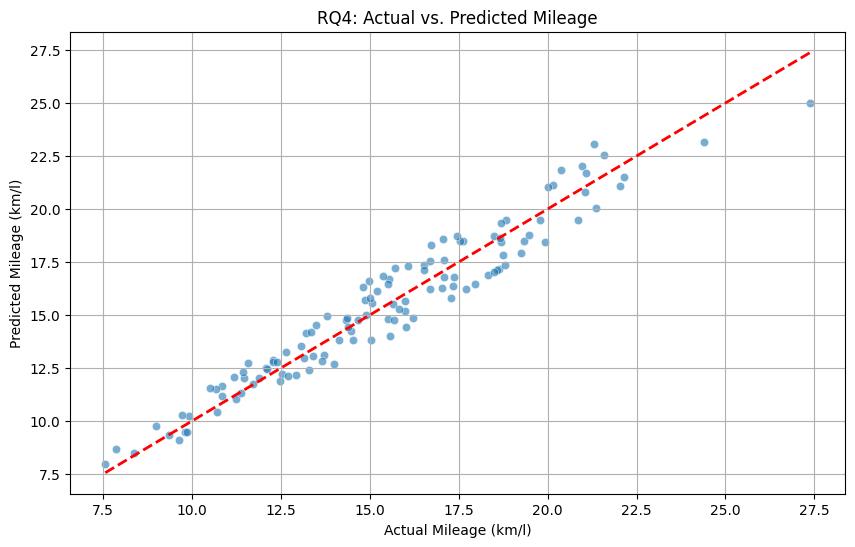

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=predictions, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('RQ4: Actual vs. Predicted Mileage')
plt.xlabel('Actual Mileage (km/l)')
plt.ylabel('Predicted Mileage (km/l)')
plt.grid(True)
plt.show()

In [20]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
gbr = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

In [22]:
gbr.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [23]:
gbr_preds = gbr.predict(X_test)

print(f"Gradient Boosting R2 Score: {r2_score(y_test, gbr_preds):.4f}")
print(f"Gradient Boosting MAE: {mean_absolute_error(y_test, gbr_preds):.4f}")

Gradient Boosting R2 Score: 0.9273
Gradient Boosting MAE: 0.8572


In [24]:
results_data = {
    'Model': ['Linear Regression', 'Gradient Boosting', 'Linear Regression', 'Gradient Boosting'],
    'Metric': ['R² Score', 'R² Score', 'MAE (Error)', 'MAE (Error)'],
    'Value': [0.9400, 0.9273, 0.8800, 0.8572]
}
res_df = pd.DataFrame(results_data)


In [26]:
from sklearn.ensemble import RandomForestRegressor

RF = RandomForestRegressor(n_estimators=500, oob_score=True, random_state=1)
RF.fit(X_train, y_train)

rf_preds = RF.predict(X_test)

print(f"Random Forest R2 Score: {r2_score(y_test, rf_preds):.4f}")
print(f"Random Forest MAE: {mean_absolute_error(y_test, rf_preds):.4f}")
print(f"Random Forest OOB Score (Internal Validation): {RF.oob_score_:.4f}")

Random Forest R2 Score: 0.9239
Random Forest MAE: 0.8597
Random Forest OOB Score (Internal Validation): 0.9318


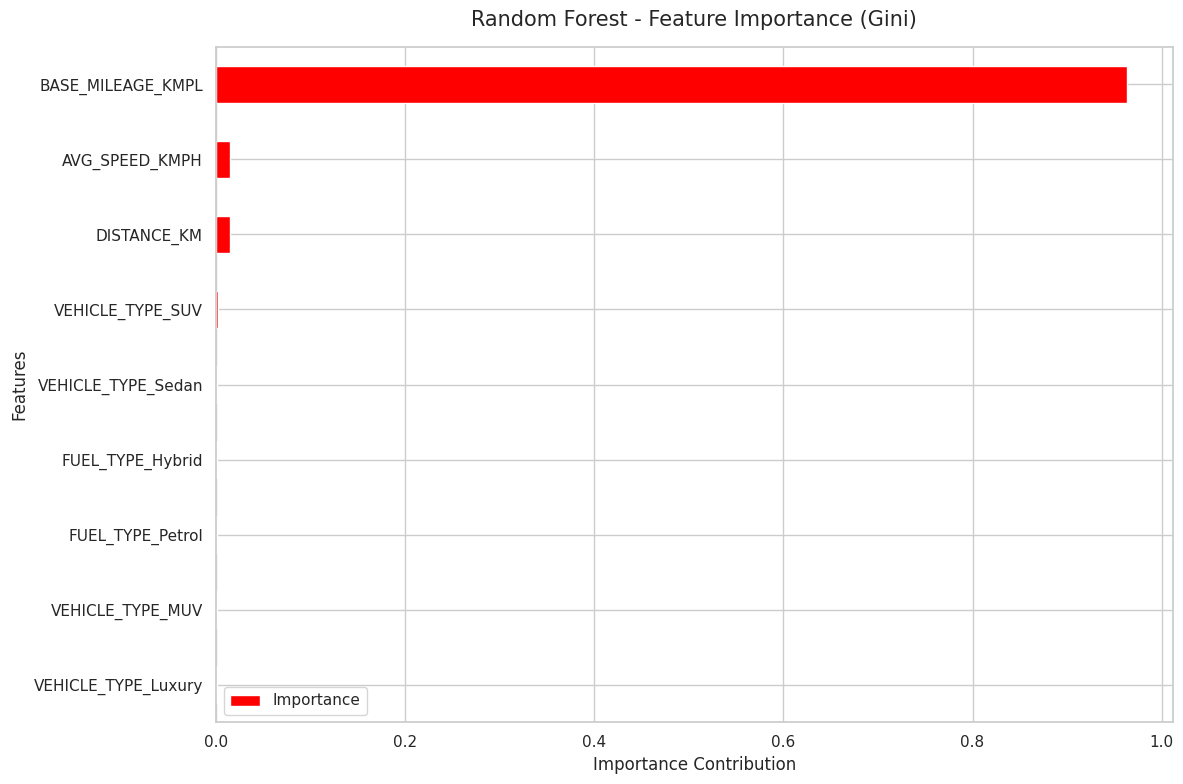

In [27]:
imp = RF.feature_importances_
df1 = pd.DataFrame({"Features": X.columns, "Importance": imp})
df1 = df1.sort_values('Importance')

df1.plot(kind='barh', color='red', x='Features', figsize=(12, 8))
plt.title('Random Forest - Feature Importance (Gini)', fontsize=15, pad=15)
plt.xlabel('Importance Contribution')
plt.tight_layout()
plt.show()

/tmp/ipykernel_15419/1619452405.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=res_df[res_df['Metric'] == 'R² Score'], x='Model', y='Value', ax=ax1, palette='Blues_d')
/tmp/ipykernel_15419/1619452405.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=res_df[res_df['Metric'] == 'MAE (Error)'], x='Model', y='Value', ax=ax2, palette='Oranges_d')


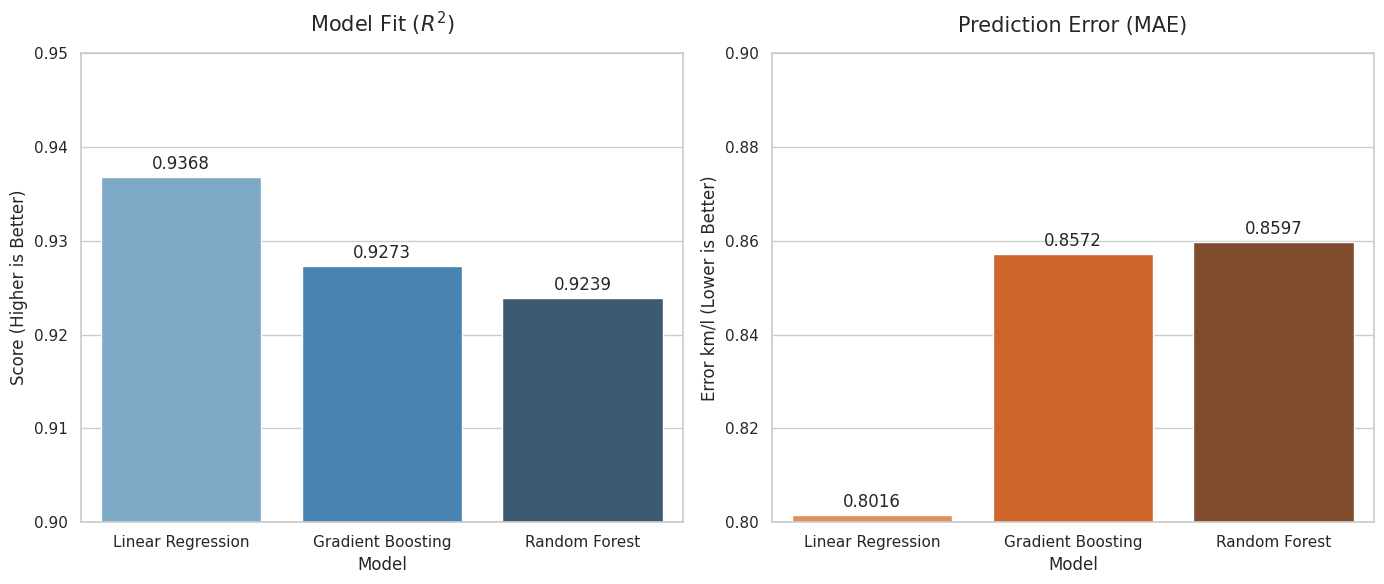

In [28]:
results_data = {
    'Model': ['Linear Regression', 'Gradient Boosting', 'Random Forest',
              'Linear Regression', 'Gradient Boosting', 'Random Forest'],
    'Metric': ['R² Score', 'R² Score', 'R² Score',
               'MAE (Error)', 'MAE (Error)', 'MAE (Error)'],
    'Value': [r2, r2_score(y_test, gbr_preds), r2_score(y_test, rf_preds),
              mae, mean_absolute_error(y_test, gbr_preds), mean_absolute_error(y_test, rf_preds)]
}
res_df = pd.DataFrame(results_data)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
sns.set_theme(style="whitegrid")

sns.barplot(data=res_df[res_df['Metric'] == 'R² Score'], x='Model', y='Value', ax=ax1, palette='Blues_d')
ax1.set_title('Model Fit ($R^2$)', fontsize=15, pad=15)
ax1.set_ylim(0.90, 0.95)
ax1.set_ylabel('Score (Higher is Better)')

sns.barplot(data=res_df[res_df['Metric'] == 'MAE (Error)'], x='Model', y='Value', ax=ax2, palette='Oranges_d')
ax2.set_title('Prediction Error (MAE)', fontsize=15, pad=15)
ax2.set_ylim(0.80, 0.90)
ax2.set_ylabel('Error km/l (Lower is Better)')

for ax in [ax1, ax2]:
    for i in ax.containers:
        ax.bar_label(i, padding=3, fmt='%.4f')

plt.tight_layout()
plt.show()